In [93]:
import pandas as pd

In [94]:
df = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [95]:
# 1. Calculate null sum
count_null = df.isnull().sum()

# 2. Transform into a DataFrame and rename columns
df_nulls = count_null.reset_index()
df_nulls.columns = ['Column', 'Null_Count']

# 3. Add percentage column for quick analysis
df_nulls['Percentage (%)'] = (df_nulls['Null_Count'] / len(df)) * 100

# Sort by most nulls
df_nulls = df_nulls.sort_values(by='Null_Count', ascending=False)

df_nulls

,Column,Null_Count,Percentage (%)
0,Review,0,0.0
1,Liked,0,0.0


In [96]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import layers

# PRE-CLEANING (Important to avoid conversion errors)
# Ensure no null values exist and force everything to string type
df['Review'] = df['Review'].fillna('').astype(str)

# 1. Preparing Labels (Restaurant Ratings)
le = LabelEncoder()
y = le.fit_transform(df['Liked']) 
num_classes = len(le.classes_)

# 2. Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['Review'], y, test_size=0.2, random_state=42
)

#DTYPE CORRECTION: Converting to String Tensors
# This ensures TensorFlow recognizes the input as a valid string array
X_train_tensor = tf.convert_to_tensor(X_train.values, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.string)

# 3. Text Vectorization Layer (Converts words to integers)
max_tokens = 100000 
sequence_length = 100 

vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)
# Adapt the layer using the training string tensor
vectorize_layer.adapt(X_train_tensor)

# 4. Neural Network Architecture with Sequential Context (LSTM)
model = tf.keras.Sequential([
    vectorize_layer,
    layers.Embedding(max_tokens, 8, mask_zero=True),
    # Bidirectional LSTM reads the text forward and backward to capture total context
    layers.Bidirectional(layers.LSTM(16, return_sequences=False)),
    layers.Dense(4, activation='relu'),
    layers.Dropout(0.2), # Marginally increased to protect the heavier LSTM layer
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training (Using the corrected tensors) - Capturing history for visualization
history = model.fit(
    X_train_tensor, 
    y_train, 
    epochs=4, 
    validation_data=(X_test_tensor, y_test), 
    batch_size=32
)

import joblib

# 1. Save the complete model (containing TextVectorization and Neural Network)
model.save('modelo_sentimento.keras')

# 2. Save the LabelEncoder to decode API outputs later
joblib.dump(le, 'label_encoder.pkl')

print("Production artifacts successfully exported!")

Epoch 1/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.5088 - loss: 0.6921 - val_accuracy: 0.4800 - val_loss: 0.6920
Epoch 2/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5425 - loss: 0.6839 - val_accuracy: 0.5900 - val_loss: 0.6850
Epoch 3/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6438 - loss: 0.6535 - val_accuracy: 0.5900 - val_loss: 0.6605
Epoch 4/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8175 - loss: 0.5550 - val_accuracy: 0.7600 - val_loss: 0.5970
Production artifacts successfully exported!


In [97]:
import numpy as np
import random

In [98]:
# Model evaluation
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_pred_probs = model.predict(X_test_tensor[:len(X_test_tensor)], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show sample predictions
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for i in random.sample(range(1, len(X_test_tensor)),k=10):
    predicted_rating = le.inverse_transform([y_pred[i]])[0]
    actual_rating = le.inverse_transform([y_test[i]])[0]
    confidence = y_pred_probs[i][y_pred[i]]
    
    print(f"\n--- Review {i} ---")
    print(f"Review Text: {X_test.iloc[i][:150]}...")
    print(f"Predicted Rating: {predicted_rating} (Confidence: {confidence*100:.2f}%)")
    print(f"Actual Rating: {actual_rating}")
    print(f"Result: {'✓ Correct' if predicted_rating == actual_rating else '✗ Incorrect'}")

MODEL EVALUATION

Test Loss: 0.5970
Test Accuracy: 0.7600 (76.00%)

SAMPLE PREDICTIONS

--- Review 26 ---
Review Text: The only good thing was our waiter, he was very helpful and kept the bloddy mary's coming....
Predicted Rating: 0 (Confidence: 52.76%)
Actual Rating: 1
Result: ✗ Incorrect

--- Review 38 ---
Review Text: Their regular toasted bread was equally satisfying with the occasional pats of butter... Mmmm...!...
Predicted Rating: 1 (Confidence: 54.36%)
Actual Rating: 1
Result: ✓ Correct

--- Review 146 ---
Review Text: The server was very negligent of our needs and made us feel very unwelcome... I would not suggest this place!...
Predicted Rating: 0 (Confidence: 89.58%)
Actual Rating: 0
Result: ✓ Correct

--- Review 42 ---
Review Text: The food was very good....
Predicted Rating: 1 (Confidence: 53.81%)
Actual Rating: 1
Result: ✓ Correct

--- Review 194 ---
Review Text: Won't go back....
Predicted Rating: 0 (Confidence: 56.95%)
Actual Rating: 0
Result: ✓ Correct

--- Review 166 

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

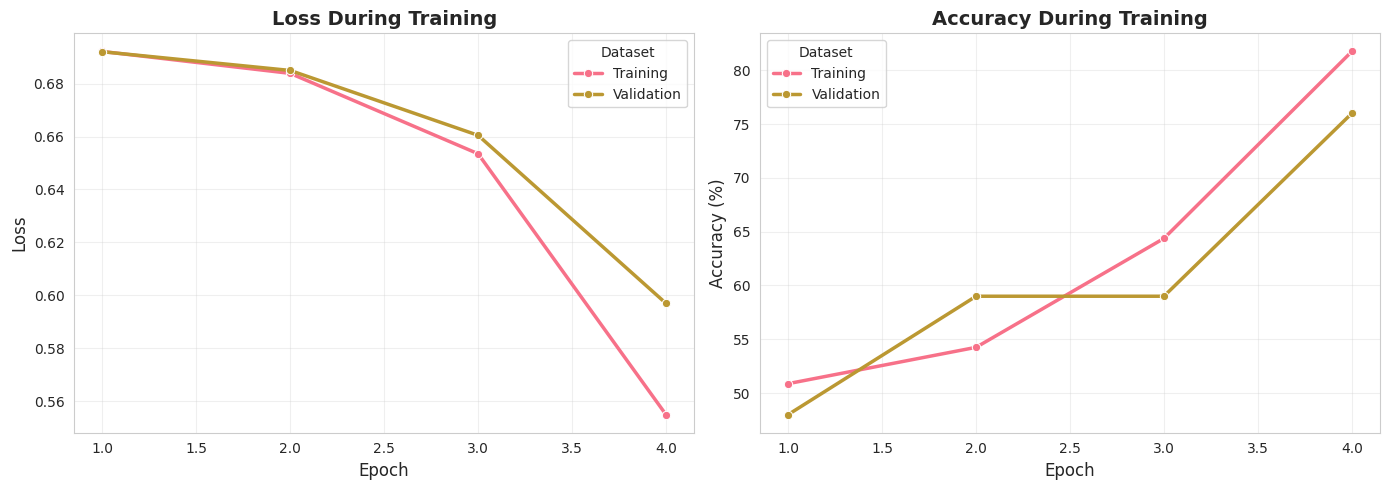


TRAINING SUMMARY

Initial Loss:      0.6921
Final Loss:        0.5550
Reduction:         19.82%

Initial Accuracy:  50.88%
Final Accuracy:    81.75%
Improvement:       30.87%

Validation Accuracy: 76.00%


In [100]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nValidation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

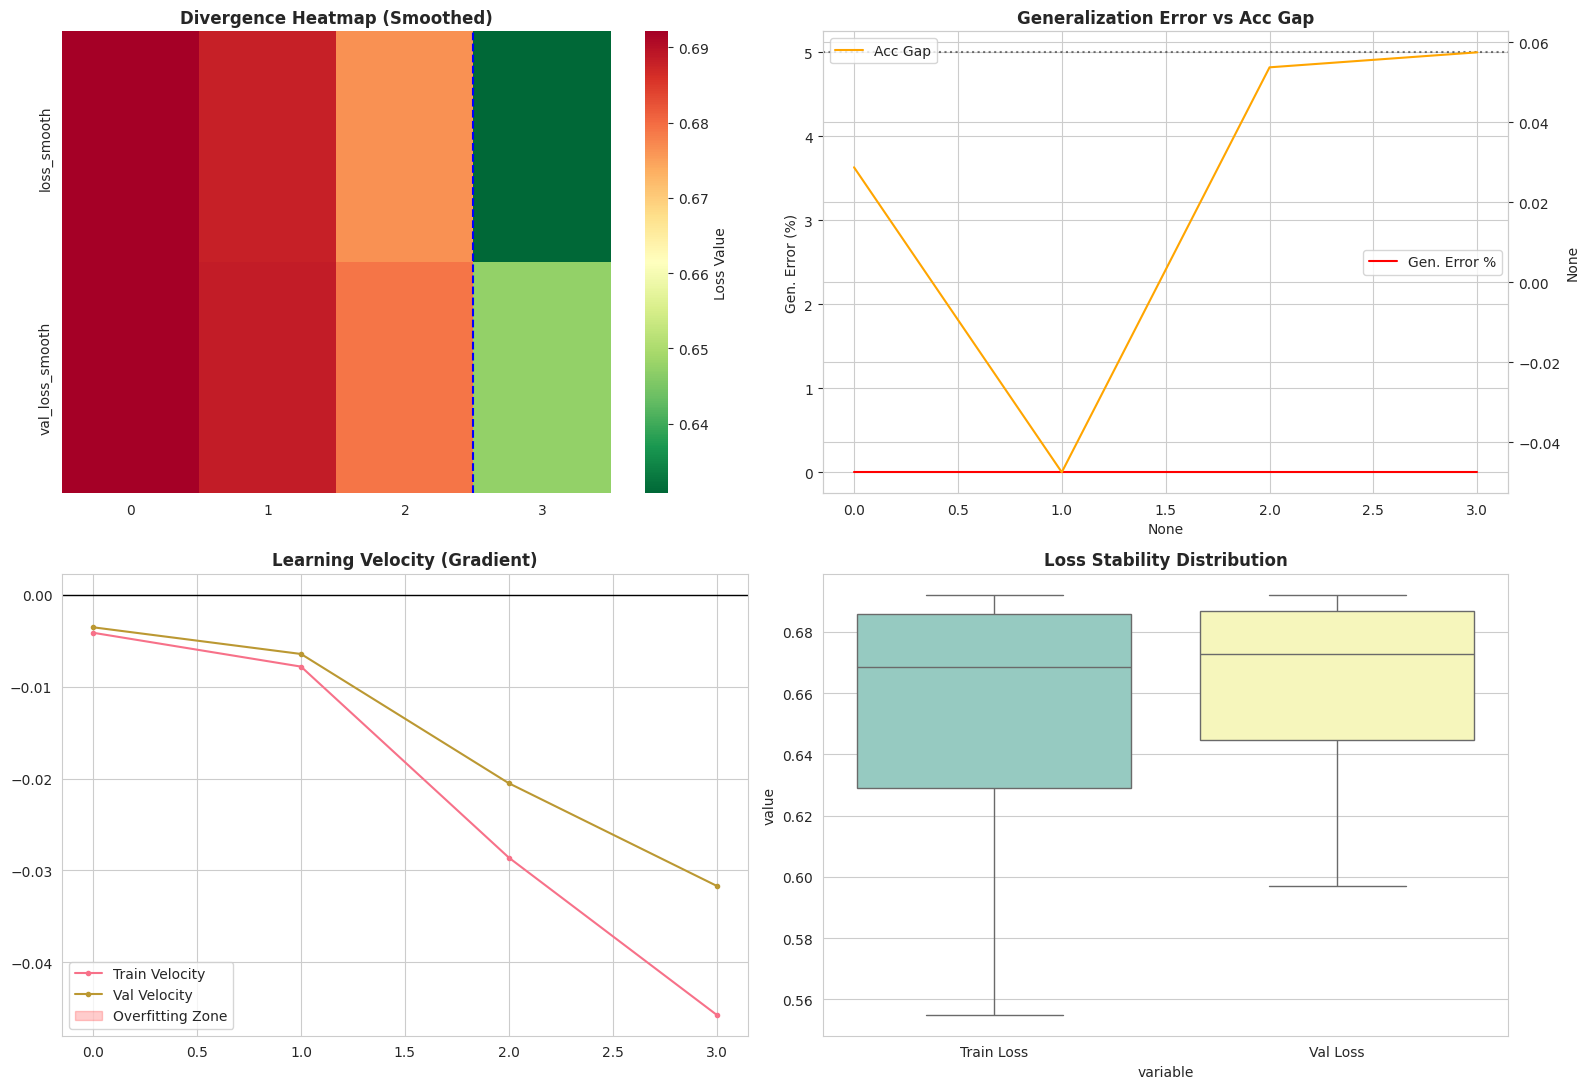


STATISTICAL OVERFITTING REPORT
Best epoch found: 3
No critical signs of overfitting detected within limits.
STATUS: ✓ STABLE MODEL
Final_Gap: 4.20%


In [101]:
# --- Data Preparation ---
# Assuming 'history_df' exists with columns: loss, val_loss, accuracy, val_accuracy
df = history_df.copy()

# 1. Smoothing (Rolling Mean) to avoid false positives caused by noise
window = 3
df['loss_smooth'] = df['loss'].rolling(window=window, min_periods=1).mean()
df['val_loss_smooth'] = df['val_loss'].rolling(window=window, min_periods=1).mean()

# 2. Generalization Error Calculation (G)
# G = 100 * (current val_loss / min val_loss so far - 1)
min_val_loss_so_far = df['val_loss'].cummin()
df['generalization_error'] = 100 * (df['val_loss'] / min_val_loss_so_far - 1)

# 3. Inflection Point Identification (Where overfitting actually begins)
best_epoch = df['val_loss'].idxmin()
overfit_epoch = df[(df.index > best_epoch) & (df['generalization_error'] > 5)].index.min()

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Smoothed Loss Heatmap (Focused on Divergence)
metrics_heatmap = df[['loss_smooth', 'val_loss_smooth']].T
sns.heatmap(metrics_heatmap, cmap='RdYlGn_r', ax=axes[0, 0], cbar_kws={'label': 'Loss Value'})
axes[0, 0].set_title('Divergence Heatmap (Smoothed)', fontweight='bold')
axes[0, 0].axvline(x=best_epoch, color='blue', linestyle='--', label='Best Model')

# Plot 2: Accuracy Gap and Generalization Error
ax2_twin = axes[0, 1].twinx()
sns.lineplot(data=df, x=df.index, y='generalization_error', ax=axes[0, 1], color='red', label='Gen. Error %')
sns.lineplot(data=df, x=df.index, y=df['accuracy'] - df['val_accuracy'], ax=ax2_twin, color='orange', label='Acc Gap')
axes[0, 1].axhline(y=5, color='black', linestyle=':', alpha=0.5) # 5% Threshold
axes[0, 1].set_title('Generalization Error vs Acc Gap', fontweight='bold')
axes[0, 1].set_ylabel('Gen. Error (%)')

# Plot 3: Loss Derivative (Learning Velocity)
train_diff = np.gradient(df['loss_smooth'])
val_diff = np.gradient(df['val_loss_smooth'])
axes[1, 0].plot(df.index, train_diff, label='Train Velocity', marker='o', markersize=3)
axes[1, 0].plot(df.index, val_diff, label='Val Velocity', marker='o', markersize=3)
axes[1, 0].axhline(y=0, color='black', lw=1)
axes[1, 0].fill_between(df.index, val_diff, where=(val_diff > 0), color='red', alpha=0.2, label='Overfitting Zone')
axes[1, 0].set_title('Learning Velocity (Gradient)', fontweight='bold')
axes[1, 0].legend()

# Plot 4: Relative Error Distribution
error_dist = pd.DataFrame({
    'Train Loss': df['loss'],
    'Val Loss': df['val_loss']
}).melt()
sns.boxplot(data=error_dist, x='variable', y='value', ax=axes[1, 1], palette='Set3', hue='variable', legend=False)
axes[1, 1].set_title('Loss Stability Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Enhanced Final Report ---
print("\n" + "=" * 50)
print("STATISTICAL OVERFITTING REPORT")
print("=" * 50)
print(f"Best epoch found: {best_epoch}")
if not np.isnan(overfit_epoch):
    print(f"Critical overfitting detected at epoch: {overfit_epoch}")
    print(f"Validation degradation since minimum: {df['generalization_error'].iloc[-1]:.2f}%")
else:
    print("No critical signs of overfitting detected within limits.")

# Severity Criteria
final_gap = df['val_loss'].iloc[-1] - df['loss'].iloc[-1]
if final_gap > 0.5:
    print(f'Final_Gap: {final_gap*100:.2f}%')
    print("STATUS: ✗ SEVERE OVERFITTING - Complexity reduction or dropout required.")
elif final_gap > 0.2:
    print("STATUS: ⚠ MODERATE OVERFITTING - Consider Early Stopping.")
    print(f'Final_Gap: {final_gap*100:.2f}%')
else:
    print("STATUS: ✓ STABLE MODEL")
    print(f'Final_Gap: {final_gap*100:.2f}%')